# European Option Pricing and Variance Reduction Techniques

---

# Objective:

- To compute and compare the prices of European call and put options using three different methods:
  - Black-Scholes closed-form solution
  - Binomial tree model
  - Monte Carlo simulation
- To validate convergence and error behavior of the Monte Carlo method.
- To analyze runtime and accuracy trade-offs using variance reduction techniques:
  - Antithetic variates
  - Control variates

---

# Methodology:

- Black-Scholes Model: Implemented the analytical formula for European call and put options assuming log-normal asset price dynamics.
- Binomial Tree Model: Constructed a recombining binomial tree with daily steps, and computed risk-neutral probabilities and asset prices at maturity.
- Monte Carlo Simulation: Simulated geometric Brownian motion paths using standard normal samples and estimated expected discounted payoff.

- Variance Reduction Techniques:
  - Antithetic Variates: Averaged payoffs from simulations using both a standard normal sample and its negative.
  - Control Variates: Used the underlying asset’s expected terminal value to reduce the variance in the payoff estimate.

- Performance Evaluation: Compared all methods against Black-Scholes as the benchmark.
- Plotted errors and runtimes across increasing number of simulations.
- Used log-log plots to confirm convergence rate proprtional to $O(1/\sqrt{N})$ for Monte Carlo methods.

---


# Key Findings:

- Accuracy:
  - All three methods produced consistent option price estimates.
  - Monte Carlo simulations converged to Black-Scholes prices as the number of simulations increased.
  - The observed error for Monte Carlo followed the theoretical convergence rate $O(1/\sqrt{N})$.

- Efficiency:
  - Black-Scholes: Fastest and most accurate for standard European options.
  - Binomial Tree: Slightly slower but reliable; suitable for American-style or path-dependent options.
  - Monte Carlo: Slower but highly flexible and generalizable.

- Variance Reduction:
  - Antithetic Variates: Provided moderate improvement in error without significant runtime increase.
  - Control Variates: Showed substantial error reduction, especially at lower simulation counts, albeit with marginally higher runtime.

- Trade-off Analysis:
  - Control variates achieved similar accuracy at a significantly lower number of simulations compared to plain Monte Carlo, reducing total computation time for a target accuracy.

---


# Conclusion:

This project demonstrates the effectiveness of different numerical methods for European option pricing, particularly emphasizing the trade-offs between accuracy and computational cost. The study highlights:

- The efficiency of the Black-Scholes model as a benchmark.
- The value of Monte Carlo simulations in complex or high-dimensional scenarios.
- The importance and effectiveness of variance reduction techniques in improving simulation-based estimators.

Such techniques are essential for practical implementations in computational finance, especially when pricing exotic derivatives or performing large-scale portfolio simulations.

---

# Code and Analysis:


Libraries:

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import math
import matplotlib.pyplot as plt
import time

np.random.seed(81)

Function to calculate option value using Black Scholes formula

In [2]:
def black_scholes_option_pricing(S0,K,T,r,sigma,option_type='call'):
    
    d1=(np.log(S0/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
    

    if option_type=='call':
        return S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
        
    elif option_type=='put':
        return K*np.exp(-r*T)*norm.cdf(-d2)-S0*norm.cdf(-d1)


Function to calculatte option price using binomial method

In [3]:
def binomial_option_pricing(S0,K,T,r,sigma,N,option_type='call'):
    
    dt=T/N
    u=np.exp(sigma * np.sqrt(dt))
    d=1/u
    
    p=(np.exp(r*dt)-d)/(u-d)
    
    asset_prices=np.array([S0*u**(N-i)*d**i for i in range(0,N+1)])
    asset_prob=np.array([math.comb(N,i)* p**(N-i)*(1-p)**i for i in range(0,N+1)])

    
    if option_type=='call':
        payoff_values=np.maximum(0,asset_prices-K)
    elif option_type=='put':
        payoff_values=np.maximum(0,K-asset_prices)

    
    return np.exp(-r*T)*np.dot(payoff_values,asset_prob)
    

Function to calculate option price using Monte Carlo simulations

In [4]:
def monte_carlo_option_pricing(S0,K,T,r,sigma,N,num_sim,option_type='call'):
    
    dt=T/N
    
    asset_path=np.zeros((num_sim,N+1))
    asset_path[:,0]=S0
    for i in range(1,N+1):
        Z=np.random.standard_normal(num_sim)
        asset_path[:,i]=asset_path[:,i-1]*np.exp((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z)
    if option_type=='call':
        payoffs=np.maximum(asset_path[:,-1]-K,0)
    elif option_type=='put':
        payoffs=np.maximum(K-asset_path[:,-1],0)


    return np.exp(-r*T)*np.mean(payoffs)


An example

In [5]:

S0=200   # Initial stock price
K=210   # Strike price
T=0.5      # Maturity time (6 months)
r=0.05   # Risk-free interest rate (5% per annum)
sigma=0.15  # Volatility (15% per annum)
N=round(T*365)   # Number of steps
num_sim=10000 # Number of simulations

bs_call_price=black_scholes_option_pricing(S0,K,T,r,sigma,option_type='call')
bs_put_price=black_scholes_option_pricing(S0,K,T,r,sigma,option_type='put')

bi_call_price=binomial_option_pricing(S0,K,T,r,sigma,N,option_type='call')
bi_put_price = binomial_option_pricing(S0,K,T,r,sigma,N,option_type='put')

mc_call_price=monte_carlo_option_pricing(S0,K,T,r,sigma,N,num_sim,option_type='call')
mc_put_price=monte_carlo_option_pricing(S0,K,T,r,sigma,N,num_sim,option_type='put')


print(f"Black Scholes model: Call option price: {bs_call_price:.3f} and Put option price: {bs_put_price:.3f}")
print(f"Binomial model: Call option price: {bi_call_price:.3f} and Put option price: {bi_put_price:.3f}")
print(f"Monte Carlo method: Call option price: {mc_call_price:.3f} and Put option price: {mc_put_price:.3f}")


Black Scholes model: Call option price: 6.367 and Put option price: 11.182
Binomial model: Call option price: 6.362 and Put option price: 11.177
Monte Carlo method: Call option price: 6.526 and Put option price: 11.014


## Part II: Monte Carlo method's error analysis and variance reduction techniques

---

Function for computing option price using Monte Carlo variance reduction techniques

In [6]:
def monte_carlo_option_pricing_vr(S0, K, T, r, sigma, N, num_sim, benchmark, option_type='call', method='plain'):

    start = time.time()
    dt = T / N

    if method == 'plain':
        
        asset_path = np.zeros((num_sim, N + 1))
        asset_path[:, 0] = S0
        for i in range(1, N + 1):
            Z = np.random.standard_normal(num_sim)
            asset_path[:, i] = asset_path[:, i - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z)

        if option_type == 'call':
            payoffs = np.maximum(asset_path[:, -1] - K, 0)
        else:
            payoffs = np.maximum(K - asset_path[:, -1], 0)

        price = np.exp(-r * T) * np.mean(payoffs)
        #error = np.exp(-r * T) * payoffs.std() / np.sqrt(num_sim)
        error = np.abs(price - benchmark)
        

    elif method == 'antithetic':
        half_sim = num_sim // 2
        asset_path = np.zeros((half_sim, N + 1))
        asset_path[:, 0] = S0

        for i in range(1, N + 1):
            Z = np.random.standard_normal(half_sim)
            asset_path[:, i] = asset_path[:, i - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z)

        if option_type == 'call':
            payoffs_1 = np.maximum(asset_path[:, -1] - K, 0)
            payoffs_2 = np.maximum(S0 * np.exp((r - 0.5 * sigma ** 2) * dt * N + sigma * np.sqrt(dt * N) * (-Z)) - K, 0)
        else:
            payoffs_1 = np.maximum(K - asset_path[:, -1], 0)
            payoffs_2 = np.maximum(K - S0 * np.exp((r - 0.5 * sigma ** 2) * dt * N + sigma * np.sqrt(dt * N) * (-Z)), 0)

        payoffs = 0.5 * (payoffs_1 + payoffs_2)
        price = np.exp(-r * T) * np.mean(payoffs)
        #error = np.exp(-r * T) * payoffs.std() / np.sqrt(half_sim)
        error = np.abs(price - benchmark)

    elif method == 'control_variate':
        half_sim = num_sim // 2
        asset_path = np.zeros((half_sim, N + 1))
        asset_path[:, 0] = S0

        for i in range(1, N + 1):
            Z = np.random.standard_normal(half_sim)
            asset_path[:, i] = asset_path[:, i - 1] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z)

        if option_type == 'call':
            payoffs = np.maximum(asset_path[:, -1] - K, 0)
        else:
            payoffs = np.maximum(K - asset_path[:, -1], 0)

        discounted_payoffs = np.exp(-r * T) * payoffs
        discounted_S_T = np.exp(-r * T) * asset_path[:, -1]

        cov_matrix = np.cov(discounted_payoffs, discounted_S_T)
        cov_payoff_asset = cov_matrix[0, 1]
        var_asset = cov_matrix[1, 1]
        beta = -cov_payoff_asset / var_asset if var_asset > 0 else 0

        adjusted_payoffs = discounted_payoffs + beta * (discounted_S_T - S0)
        price = np.mean(adjusted_payoffs)
        #error = np.std(adjusted_payoffs) / np.sqrt(half_sim)
        error = np.abs(price - benchmark)

    else:
        raise ValueError("Method must be one of 'plain', 'antithetic', or 'control_variate'.")

    end = time.time()
    runtime = end - start

    return price, error, runtime


In [7]:
methods = ['plain', 'antithetic', 'control_variate']
num_sim_arr = np.linspace(100, 10**5, 25, dtype=int)

prices = {m: [] for m in methods}
errors = {m: [] for m in methods}
runtimes = {m: [] for m in methods}



for num_sim in num_sim_arr:
    for m in methods:
        price, error, time_ = monte_carlo_option_pricing_vr(S0, K, T, r, sigma, N, num_sim, bs_call_price, option_type='call', method=m)
        prices[m].append(price)
        errors[m].append(error)
        runtimes[m].append(time_)


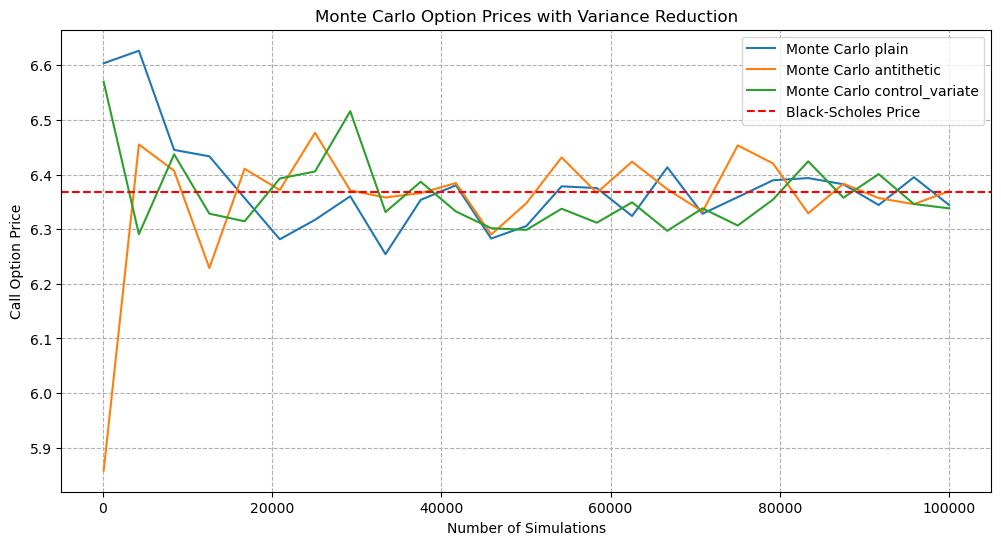

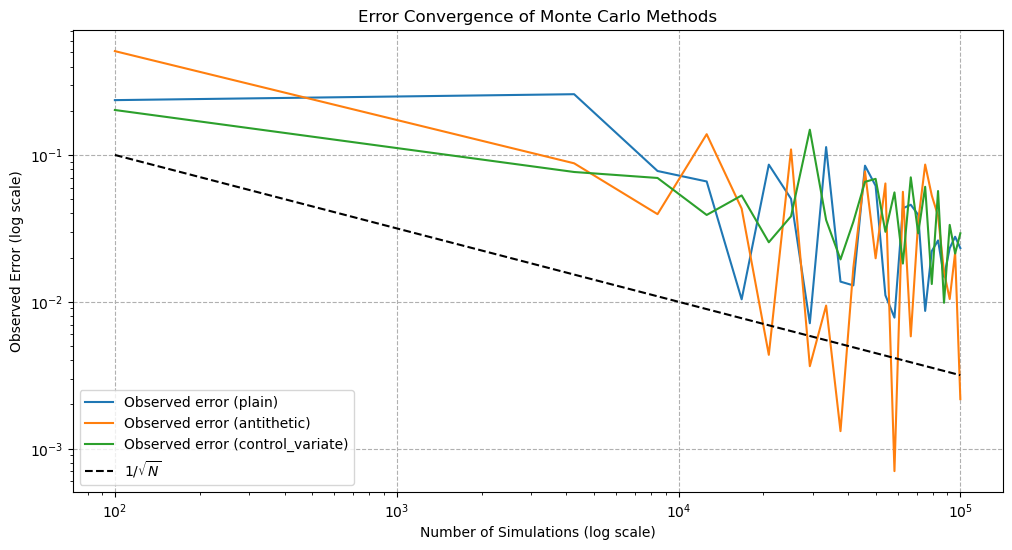

In [8]:
plt.figure(figsize=(12, 6))
for m in methods:
    plt.plot(num_sim_arr, prices[m], label=f'Monte Carlo {m}')
plt.axhline(y=bs_call_price, color='r', linestyle='--', label='Black-Scholes Price')
plt.xlabel('Number of Simulations')
plt.ylabel('Call Option Price')
plt.title('Monte Carlo Option Prices with Variance Reduction')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

plt.figure(figsize=(12, 6))
for m in methods:
    #observed_error = np.abs(np.array(prices[m]) - bs_call_price)
    plt.loglog(num_sim_arr, errors[m], label=f'Observed error ({m})')
plt.loglog(num_sim_arr, 1/np.sqrt(num_sim_arr), 'k--', label=r'$1/\sqrt{N}$')
plt.xlabel('Number of Simulations (log scale)')
plt.ylabel('Observed Error (log scale)')
plt.title('Error Convergence of Monte Carlo Methods')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [9]:
comparison_data = pd.DataFrame({"Price(Plain)": prices["plain"], "Price(Antithetic)": prices["antithetic"], "Price(CV)": prices["control_variate"],
              "Runtime(plain)": runtimes["plain"], "Runtime(Antithetic)": runtimes["antithetic"], "Runtime(CV)": runtimes["control_variate"],
              "Error(plain)": errors["plain"], "Error(Antithetic)": errors["antithetic"], "Error(CV)": errors["control_variate"]},
             index = num_sim_arr)
comparison_data.index.name = "Simulations"

print(comparison_data)

             Price(Plain)  Price(Antithetic)  Price(CV)  Runtime(plain)  \
Simulations                                                               
100              6.603687           5.857765   6.569798        0.003401   
4262             6.626699           6.455114   6.290837        0.033063   
8425             6.445145           6.406906   6.437097        0.045255   
12587            6.433374           6.228892   6.328368        0.073125   
16750            6.357000           6.410493   6.314399        0.098693   
20912            6.281487           6.371742   6.392817        0.126455   
25075            6.317102           6.476472   6.405611        0.156586   
29237            6.360249           6.371031   6.515998        0.186108   
33400            6.254235           6.357966   6.331331        0.215964   
37562            6.353676           6.366075   6.386825        0.245259   
41725            6.380318           6.384502   6.332306        0.312433   
45887            6.282847

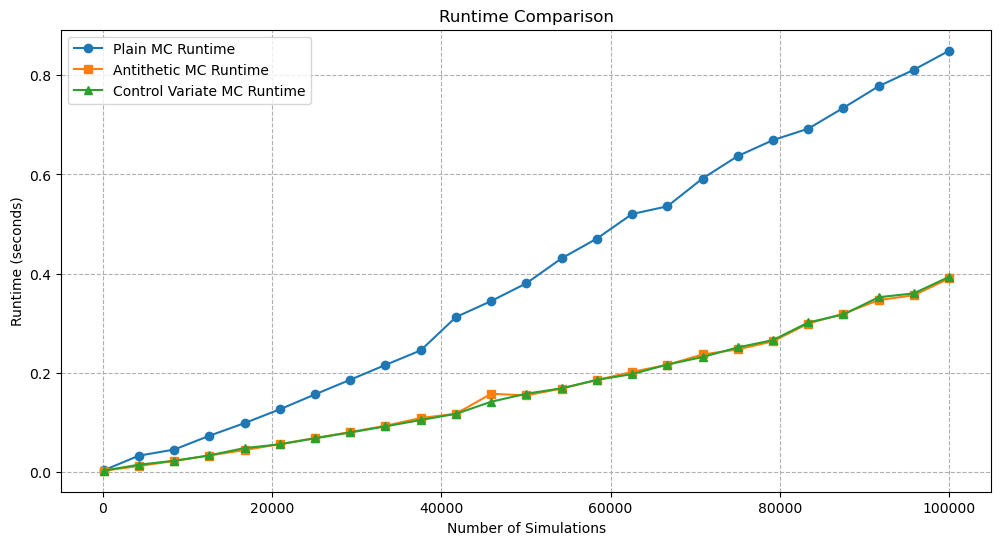

In [10]:

plt.figure(figsize=(12, 6))

plt.plot(comparison_data.index, comparison_data['Runtime(plain)'], marker='o', label='Plain MC Runtime')
plt.plot(comparison_data.index, comparison_data['Runtime(Antithetic)'], marker='s', label='Antithetic MC Runtime')
plt.plot(comparison_data.index, comparison_data['Runtime(CV)'], marker='^', label='Control Variate MC Runtime')


plt.xlabel('Number of Simulations')
plt.ylabel('Runtime (seconds)')
plt.title('Runtime Comparison')
plt.legend()
plt.grid(True, linestyle='--')

plt.show()
